In [ ]:
#动量表象的密度作为可观测量构成影子态

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Operator, Statevector
from qiskit.circuit.library import QFT
from scipy.linalg import eigh
from numpy import pi, exp, sqrt, real, imag

# ================================== 基本设置 ==================================
nx = ny = 3
N = 2**nx
x = np.linspace(-pi, pi, N, endpoint=False)
y = np.linspace(-pi, pi, N, endpoint=False)
X, Y = np.meshgrid(x, y)
dx = 2*pi/N

# ================================== 初始态 ==================================
x0, y0 = 0, 0
R = np.sqrt((X - x0)**2 + (Y - y0)**2)
sigma = 3
f = exp(-(R/sigma)**4)
u = 2*(X + 1j*Y)*f / (1 + R**2)
v = 1j*(R**2 + 1 - 2*f) / (1 + R**2)
psi1_0 = u / sqrt(abs(u)**2 + abs(v)**4)
psi2_0 = v**2 / sqrt(abs(u)**2 + abs(v)**4)
initial_state = np.array([psi1_0, psi2_0]).reshape(-1)
initial_state = initial_state / np.linalg.norm(initial_state)

# ================================== 动量密度算符构造 ==================================
def get_momentum_density_observables(nx, ny):
    """
    构造动量表象下的密度观测算符集合：|k⟩⟨k|_1 + |k⟩⟨k|_2
    """
    N = 2**nx
    qft = Operator(QFT(nx, do_swaps=False)).data
    qft2d = np.kron(qft, qft)
    iqft2d = qft2d.conj().T

    observables = []
    for i in range(N*N):
        O_k = np.zeros((N*N, N*N), dtype=complex)
        O_k[i, i] = 1.0
        O_x = iqft2d @ O_k @ qft2d

        O_full = np.zeros((2*N*N, 2*N*N), dtype=complex)
        O_full[:N*N, :N*N] = O_x
        O_full[N*N:, N*N:] = O_x
        observables.append(O_full)
    return observables

# ================================== 核心函数 ==================================
# 全态演化与涡度计算
def compute_vorticity(psi1, psi2, N):
    kx = np.fft.fftfreq(N)*N
    ky = np.fft.fftfreq(N)*N
    KX, KY = np.meshgrid(kx, ky)
    psi1_spec = np.fft.fft2(psi1)
    dpsi1_x = np.fft.ifft2(1j*KX*psi1_spec)
    dpsi1_y = np.fft.ifft2(1j*KY*psi1_spec)
    psi2_spec = np.fft.fft2(psi2)
    dpsi2_x = np.fft.ifft2(1j*KX*psi2_spec)
    dpsi2_y = np.fft.ifft2(1j*KY*psi2_spec)
    rho = np.abs(psi1)**2 + np.abs(psi2)**2
    ux = real(real(psi1)*imag(dpsi1_x) - imag(psi1)*real(dpsi1_x) + real(psi2)*imag(dpsi2_x) - imag(psi2)*real(dpsi2_x)) / rho
    uy = real(real(psi1)*imag(dpsi1_y) - imag(psi1)*real(dpsi1_y) + real(psi2)*imag(dpsi2_y) - imag(psi2)*real(dpsi2_y)) / rho
    vor = real(np.fft.ifft2(1j*KX*np.fft.fft2(uy) - 1j*KY*np.fft.fft2(ux)))
    return vor

def evolve(nx, ny, dt, initial_state):
    q_num = nx + ny + 1
    circ = QuantumCircuit(q_num)
    circ.initialize(initial_state)
    circ.barrier()

    QFT_x = QFT(nx)
    QFT_y = QFT(ny)
    IQFT_x = QFT(nx).inverse()
    IQFT_y = QFT(ny).inverse()

    def kinetic_operator(n, dt):
        qc = QuantumCircuit(n)
        qc.rz(-2**(n-1)*dt, n-1)
        for i in range(n):
            qc.rz(2**(n-i-2)*dt, n-i-1)
        for i in range(1, n):
            qc.cx(n-1, n-i-1)
            qc.rz(-2**(2*n-i-2)*dt, n-i-1)
            qc.cx(n-1, n-i-1)
        for i in range(n):
            for j in range(n):
                if i != j:
                    qc.cx(n-i-1, n-j-1)
                    qc.rz(2**(2*n-i-j-4)*dt, n-j-1)
                    qc.cx(n-i-1, n-j-1)
        return qc

    kinetic_x = kinetic_operator(nx, dt)
    kinetic_y = kinetic_operator(ny, dt)

    circ.append(QFT_x, range(nx))
    circ.append(QFT_y, range(nx, nx+ny))
    circ.barrier()
    circ.append(kinetic_x, range(nx))
    circ.append(kinetic_y, range(nx, nx+ny))
    circ.barrier()
    circ.append(IQFT_x, range(nx))
    circ.append(IQFT_y, range(nx, nx+ny))
    circ.save_statevector()

    simulator = AerSimulator(method='statevector')
    circ = transpile(circ, simulator)
    result = simulator.run(circ).result()
    return np.array(result.data(0)['statevector'])

def get_expectation(statevec, observables):
    return [np.real(statevec.conj().T @ (O @ statevec)) for O in observables]

def build_shadow_evolution_circuit(H_S, init_expvals, t):
    M = len(init_expvals)
    psi0 = np.array(init_expvals, dtype=complex)
    psi0 /= np.linalg.norm(psi0)
    n_shadow = int(np.ceil(np.log2(M)))
    dim = 2**n_shadow
    init_state = np.zeros(dim, dtype=complex)
    init_state[:M] = psi0

    eigvals, V = eigh(H_S)
    U_s = V @ np.diag(np.exp(-1j * eigvals * t)) @ V.conj().T
    U_pad = np.eye(dim, dtype=complex)
    U_pad[:M, :M] = U_s

    circ = QuantumCircuit(n_shadow)
    circ.initialize(init_state, range(n_shadow))
    circ.append(Operator(U_pad), range(n_shadow))
    circ.save_statevector()
    return circ, n_shadow

def construct_kinetic_H_phys(N):
    k = np.fft.fftfreq(N) * N
    KX, KY = np.meshgrid(k, k)
    Lap = -(KX**2 + KY**2)
    T = np.diag(Lap.flatten())

    qft_circ = QFT(int(np.log2(N)), do_swaps=False)
    qft = Operator(qft_circ).data
    qft2d = np.kron(qft, qft)
    iqft2d = qft2d.conj().T

    T_pos = iqft2d @ T @ qft2d

    H_phys = np.zeros((2*N*N, 2*N*N), dtype=complex)
    H_phys[:N*N, :N*N] = T_pos
    H_phys[N*N:, N*N:] = T_pos
    return H_phys

def construct_shadow_HS_commutator(H_phys, observables):
    M = len(observables)
    D = H_phys.shape[0]
    H_S = np.zeros((M, M), dtype=complex)
    for m, Om in enumerate(observables):
        comm = H_phys @ Om - Om @ H_phys
        for n, On in enumerate(observables):
            H_S[m, n] = 1j * np.trace(On.conj().T @ comm) / D
    H_S = (H_S + H_S.conj().T) / 2
    return H_S




In [5]:
# ================================== 主流程 ==================================
dt = np.pi
state_0 = evolve(nx, ny, 0.0, initial_state)
observables = get_momentum_density_observables(nx, ny)
H_phys = construct_kinetic_H_phys(N)
H_S = construct_shadow_HS_commutator(H_phys, observables)
print("H_S norm =", np.linalg.norm(H_S))
print("H_S (submatrix):\n", H_S[:5, :5])


H_S norm = 5.715756616594477e-17
H_S (submatrix):
 [[-6.82501184e-19+0.00000000e+00j  0.00000000e+00-1.92592994e-34j
   4.57284942e-21+2.93443468e-21j -7.10071337e-21-6.83674820e-21j
   3.53984946e-20+1.97016160e-20j]
 [ 0.00000000e+00+1.92592994e-34j  3.34590799e-20+0.00000000e+00j
  -1.35638121e-21+1.30073006e-21j  6.45181379e-21-1.01039107e-20j
   2.52340993e-20-4.12847562e-20j]
 [ 4.57284942e-21-2.93443468e-21j -1.35638121e-21-1.30073006e-21j
  -1.29997589e-18+0.00000000e+00j  2.21473696e-20+3.32883948e-19j
  -2.04510156e-20-3.02395855e-20j]
 [-7.10071337e-21+6.83674820e-21j  6.45181379e-21+1.01039107e-20j
   2.21473696e-20-3.32883948e-19j -2.27109201e-18+0.00000000e+00j
  -2.34163119e-20-2.86925621e-20j]
 [ 3.53984946e-20-1.97016160e-20j  2.52340993e-20+4.12847562e-20j
  -2.04510156e-20+3.02395855e-20j -2.34163119e-20+2.86925621e-20j
   1.02908750e-17+0.00000000e+00j]]


In [7]:
init_expect = get_expectation(state_0, observables)
shadow_circ, n_shadow = build_shadow_evolution_circuit(H_S, init_expect, t=dt)
sim = AerSimulator(method='statevector')
shadow_circ = transpile(shadow_circ, sim)
result = sim.run(shadow_circ).result()
statevec_shadow = np.array(Statevector(result.data(0)['statevector']))
shadow_expect = np.real(statevec_shadow[:len(observables)]) * np.linalg.norm(init_expect)



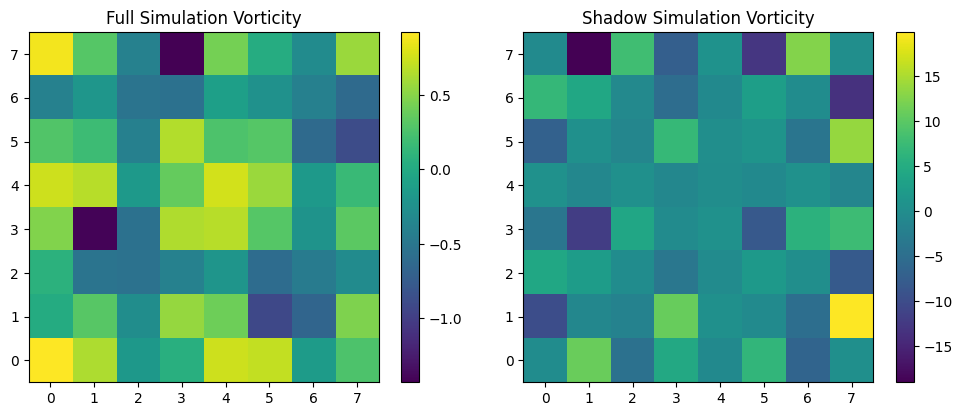

In [9]:
state_1 = evolve(nx, ny, dt, initial_state)
psi1 = state_1[:N*N].reshape((N, N))
psi2 = state_1[N*N:].reshape((N, N))
vor_full = compute_vorticity(psi1, psi2, N)

# 影子态重建：仅用 shadow_expect 重构 ψ1 近似态
rho_shadow = np.array(shadow_expect[:N*N]).reshape(N, N)
psi1_shadow = np.sqrt(rho_shadow + 1e-12)
psi2_shadow = np.zeros_like(psi1_shadow)
vor_shadow = compute_vorticity(psi1_shadow, psi2_shadow, N)

# 可视化对比
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
im0 = axs[0].imshow(vor_full, origin='lower', cmap='viridis')
axs[0].set_title("Full Simulation Vorticity")
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(vor_shadow, origin='lower', cmap='viridis')
axs[1].set_title("Shadow Simulation Vorticity")
plt.colorbar(im1, ax=axs[1])

plt.tight_layout()
plt.show()
